# Sleep Logs Analysis

# Intro

This article intends to provide complete analysis of given sleep logs. The purposes of the analysis are: 

- Ensure the quality of sleep at the present time;
- Define main external and internal factors influence the quality of sleep and well being;
- Develop a plan to improve, maintain, and enhance quality of sleep.

So the information presented here will be more focused on the analysis data itself than its preparing and formatting techniques. But it will have well documented source code and brief explanations in the article itself.

# Data and Methodology

Future methods of processing the data depends on given sources. There will be presented data from two distinct tables of different formats: **markdown** - `.md`, and **comma-separated values (CSV)** - `.txt` or `.csv`. The data of these sources must follow common table structure for future processing and interpreting. That's why these files will undergo several stages of the preparatory process, **scv-source** table's format chosen as more preferable due it's data precision:

1. Fetching **markdown** table by title (source code `md_extract`):
   This is performed in `md_extract.py` by using such packages as [Markdown](https://pypi.org/project/Markdown/) and [Beautiful Soup](https://pypi.org/project/beautifulsoup4/);
4. Renaming columns of the **md-source** table to match the names of the **csv-source** table;
5. Adding new and removing unnecessry columns to the **md-source** for compatibility with **csv-source**;
6. Changing `Duration` column to timestamp to make it easier to operate with;
7. Generate dates for rows, **md-source** has data aranged sequentially in ascending date order.
   The earliest day of the **csv_source** used for generation;
8. Formatting **Sleep Time** and **Wake Time** of the both tables.
9. Finally, concatination of two tables to get data in a single-form table.

## Brief explanation of Summary analysis

TODO

## Brief explanation of Plots Analysis

TODO

# Verify prepared tables

In [1]:
from tables_prep import sleep_logs as sl

sl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2025-12-14 to 2025-10-26
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   Sleep Time  60 non-null     object         
 1   Wake Time   60 non-null     object         
 2   Duration    60 non-null     timedelta64[ns]
 3   Notes       35 non-null     object         
dtypes: object(3), timedelta64[ns](1)
memory usage: 2.3+ KB


# Deviation

In [2]:
sl = sl.sort_index(ascending=False)

# Utility fuction for getting first value of the past_week
def print_summary_val(s):
    global past_week
    summary = past_week.describe().loc[s].values[0]

    hours = summary.seconds // 60 // 60
    minutes = summary.seconds // 60 % 60
    seconds = summary.seconds % 60
    
    if summary.days != 0:
        print(f"{s}: {summary.days} {hours}:{minutes}:{seconds}")
    else:
        print(f"{s}: {hours}:{minutes}:{seconds}")

past_week = sl.head(7)
past_week.describe()

,Duration
count,7
mean,0 days 07:22:00
std,0 days 00:43:04.182656082
min,0 days 05:55:00
25%,0 days 07:17:00
50%,0 days 07:39:00
75%,0 days 07:45:30
max,0 days 07:55:00


## Mean

In [3]:
print_summary_val('mean')

mean: 7:22:0


The value of `mean` shows an average sleep time over the past week that is approximately 22 minutes above the [U.S Centers for Desease Control and Prevention](https://www.cdc.gov/sleep/about/?CDC_AAref_Val=https://www.cdc.gov/sleep/about_sleep/how_much_sleep.html) recommended daily sleep amount of more then 7 hours for **adult**.

## Standard deviation and weekly quality

In [4]:
print_summary_val('std')

std: 0:43:4


In [5]:
import numpy as np

# Utility function for future use
def get_z(days):
    global min_recommend
    mean = days.describe().loc['mean'].values[0]
    std = days.describe().loc['std'].values[0]
    return (min_recommend - mean) / std

min_recommend = np.timedelta64(7, 'h')

z = get_z(past_week)

print(f"{z:.2f}")

-0.51


Standard deviation (~43 minutes) and the `mean` time (7 hours 22 minutes) gives a Z-value ($-0.51$). Resulting Z-value means rate of days less than minimum recommended is $≈30.5\%$. Check [Z-table](https://en.wikipedia.org/wiki/Standard_normal_table#Cumulative_from_minus_infinity_to_Z) to verify.

# Boxplot

Preparation of the table to consist only necessary data for a boxplot.

In [6]:
import pandas as pd
import numpy as np

week_days = (
    sl[['Duration']]
    # Transform the Duration from timedelta to hours in float
    .map(lambda td: td.seconds / (60 * 60))
    # Apply days to the dataframes
    .assign(**{'Day': sl.index.isocalendar().day})
)

Create a `boxplot` and decorate it

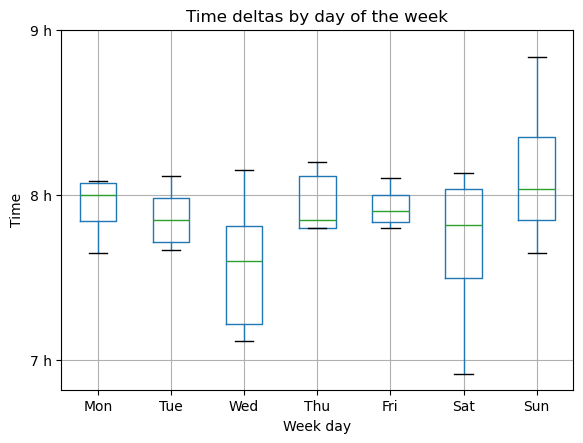

In [7]:
import decorate
import matplotlib.pyplot as plt

ax = week_days.boxplot(by='Day', sym='')

decorate.weekdays_boxplot(ax, week_days)

plt.show()

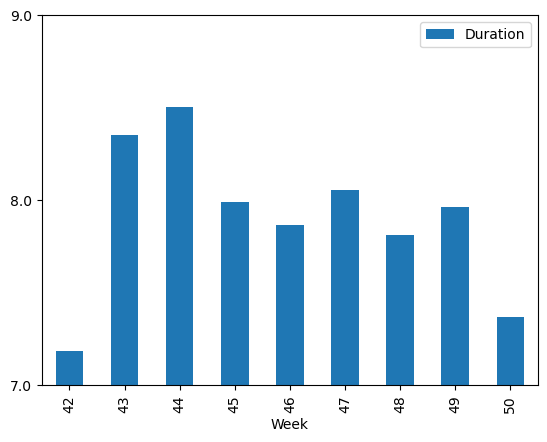

In [8]:
df = (
    sl[['Duration']]
    .map(lambda td: td.seconds / (60 * 60))
    .assign(**{
        'Week': sl.index.isocalendar().week,
    })
    .groupby('Week')
    .mean()
)

import numpy as np
import decorate

COL = 'Duration'
lowest = decorate.get_quartile(df, '25%', column=COL)
highest = (decorate.get_quartile(df, '75%', column=COL) + 1)
del COL

df = df.map(lambda h: h)
ax = df.plot.bar()

ax.set_ylim(lowest, highest)

ax.set_yticks(
    np.linspace(lowest, highest, 3),
    labels=np.linspace(lowest, highest, 3)
)

plt.show()

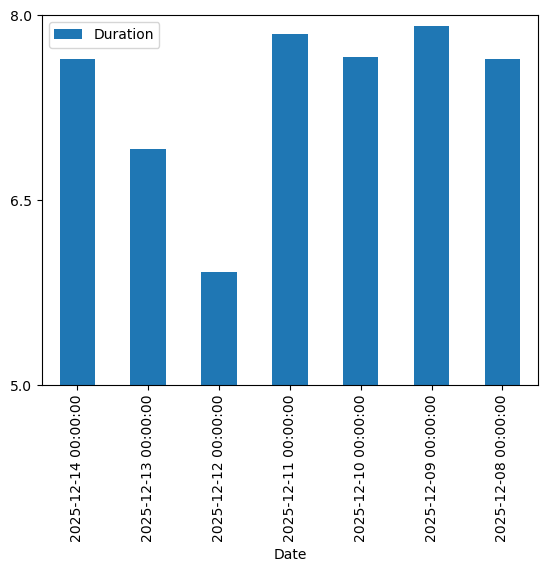

In [9]:
df = (
    sl[['Duration']].head(7)
    .map(lambda td: td.seconds / (60 * 60))
)

import numpy as np
import decorate

COL = 'Duration'
lowest = decorate.get_quartile(df, 'min', column=COL)
highest = (decorate.get_quartile(df, 'max', column=COL) + 1)
del COL

df = df.map(lambda h: h)
ax = df.plot.bar()

ax.set_ylim(lowest, highest)

ax.set_yticks(
    np.linspace(lowest, highest, 3),
    labels=np.linspace(lowest, highest, 3)
)

plt.show()

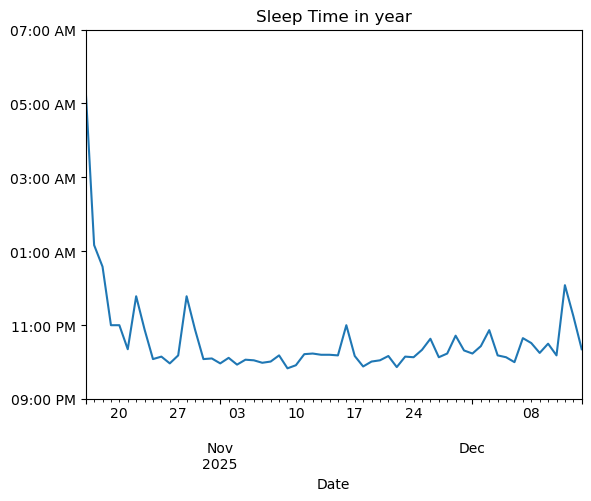

In [10]:
import re
import math
import util

COL = 'Sleep Time'
DT = pd.to_datetime("1900-01-01")
FMT = "%I:%M %p"

st = (
    pd.to_datetime(sl[COL], format=FMT) - DT
)

inc = lambda dt: np.timedelta64(24, 'h') + dt
c = sl[COL].str.match(r'\d\d:\d\d AM').values
def normalize_dt(dt):
    DAY_IN_SEC = 24 * 60**2
    sec = dt.seconds + dt.days * DAY_IN_SEC
    return sec / DAY_IN_SEC

st = (
    pd.Series(st)
    .mask(c, inc)
    .apply(normalize_dt)
)

ax = st.plot()
lowest = math.floor(util.round_f(st.min(), 1, 'floor') * 24) / 24
highest = math.floor(util.round_f(st.max(), 1, 'ceil') * 24) / 24
ticks = np.linspace(lowest, highest, 6)
labels = (DT + pd.to_timedelta(ticks * 24 % 24, 'h')).strftime(FMT)
ax.set_yticks(ticks, labels)
ax.set_title("Sleep Time in year")
plt.show()

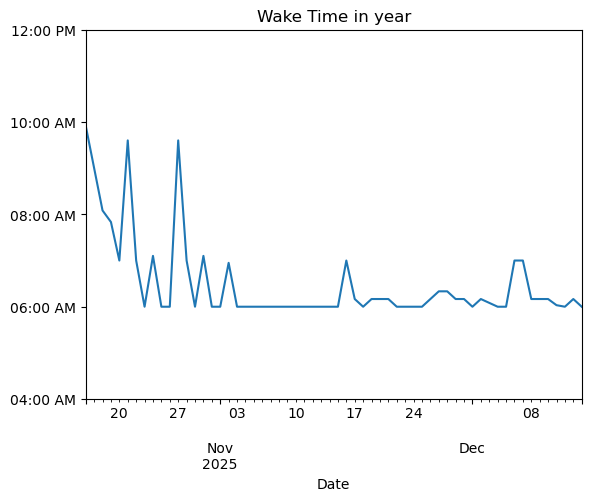

In [11]:
import re
import math
import util

COL = 'Wake Time'
DT = pd.to_datetime("1900-01-01")
FMT = "%I:%M %p"

st = (
    pd.to_datetime(sl[COL], format=FMT) - DT
)

inc = lambda dt: np.timedelta64(24, 'h') + dt
c = sl[COL].str.match(r'\d\d:\d\d AM').values
def normalize_dt(dt):
    DAY_IN_SEC = 24 * 60**2
    sec = dt.seconds + dt.days * DAY_IN_SEC
    return sec / DAY_IN_SEC

st = (
    pd.Series(st)
    .mask(c, inc)
    .apply(normalize_dt)
)

ax = st.plot()
lowest = math.floor(util.round_f(st.min(), 1, 'floor') * 24) / 24
highest = math.floor(util.round_f(st.max(), 1, 'ceil') * 24) / 24
ticks = np.linspace(lowest, highest, 5)
labels = (DT + pd.to_timedelta(ticks * 24 % 24, 'h')).strftime(FMT)
ax.set_yticks(ticks, labels)
ax.set_title("Wake Time in year")
plt.show()

# References

- [Markdown Official Website](https://daringfireball.net/projects/markdown/)
- [Beautiful Soup Official Website](https://www.crummy.com/software/BeautifulSoup/)
- [Markdown in PyPI](https://pypi.org/project/Markdown/)
- [Beautiful Soup in PyPI](https://pypi.org/project/beautifulsoup4/)